# Bootcamp: From Data to Prediction - Supervised Learning Path
## HARI 3: Supervised Learning - Regression Path
Selamat datang di fase *Predictive Analytics*! Hari ini kita akan membangun Machine Learning yang tidak lagi sekadar membaca masa lalu, melainkan memprediksi nilai angka di masa depan.

### Metodologi Standar Industri: CRISP-DM
Sesuai standar global Data Science, kita akan membedah proyek kita menggunakan kerangka **CRISP-DM (Cross-Industry Standard Process for Data Mining)**:
1. **Business Understanding:** Mendefinisikan masalah dan tujuan.
2. **Data Understanding:** Audit anatomi data dan visualisasi pola.
3. **Data Preparation:** Transformasi teks ke angka dan *Data Splitting*.
4. **Modeling:** Melatih dan membedah cara kerja 3 Algoritma Regresi.
5. **Evaluation:** Mengukur tingkat *Error* untuk memilih model terbaik.

In [40]:
# Import library standar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import library Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
print("Library Machine Learning siap digunakan!")

Library Machine Learning siap digunakan!


## BAB 1: Business Understanding

**Studi Kasus: Prediksi Premi Asuransi Kesehatan (Health Insurance)**
Perusahaan asuransi sering kesulitan menentukan **Tarif Premi Bulanan** yang adil untuk nasabah baru secara instan. Menghitung risiko secara manual rawan *human error*.

* **Tujuan Utama (Goal):** Menciptakan model Machine Learning yang mampu memprediksi **Biaya Premi (`charges`)** secara otomatis berdasarkan profil kesehatan nasabah.
* **Pendekatan AI:** `Supervised Learning - Regression`. Karena target prediksinya ($Y$) berupa angka pecahan/kontinu (Dollar), bukan label kelas/kategori.

## BAB 2: Data Understanding
Sebelum melatih algoritma, kita wajib melakukan audit awal (Profiling) untuk mengenali dimensi data, mengecek kecacatan, dan melihat pola sebaran data mentah.

### 2.1 Data Profiling & Audit Struktur

In [41]:
# Load Dataset Asuransi
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

# Audit Dimensi & Data Kosong
print(f"Total Baris :  {df.shape[0]}")
print(f"Total Kolom :  {df.shape[1]}")

print("========" * 12)

# Tampilkan 3 baris sampel
df.info()

print("========" * 12)

df.sample(3)

print("========" * 12)

display(df.describe(include="all"))

print("========" * 12)


# INSIGHT:

# Business understanding berupa hasil algo ML untuk prediksi charge secara otomatis berdasarkan profil kesehatan nasabah, dan itu data yg cukup untuk training
# Feature mapping (var input dipakai model untuk belajar pattern) di analisa tipe datanya, info, dan describe, demi preprocessing
# Data profiling tersebut membantu kita berpikir mathematical representation dan membangun statistical dataset intuition
# Data operasi statistikl mampu membantu kita mendapat gambaran atas pengaruh antar data feature kepada charge

# Focus : Data health, feature, encoding, missing value, dst, outlier, skewness, scaling, model

Total Baris :  1338
Total Kolom :  7
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


### 2.2 Exploratory Visual: Korelasi Merokok vs Biaya Premi
Mari kita buktikan secara visual faktor apa yang paling membuat harga premi meledak. Kita buat *Scatter Plot* antara Umur, Biaya, dan Status Perokok.

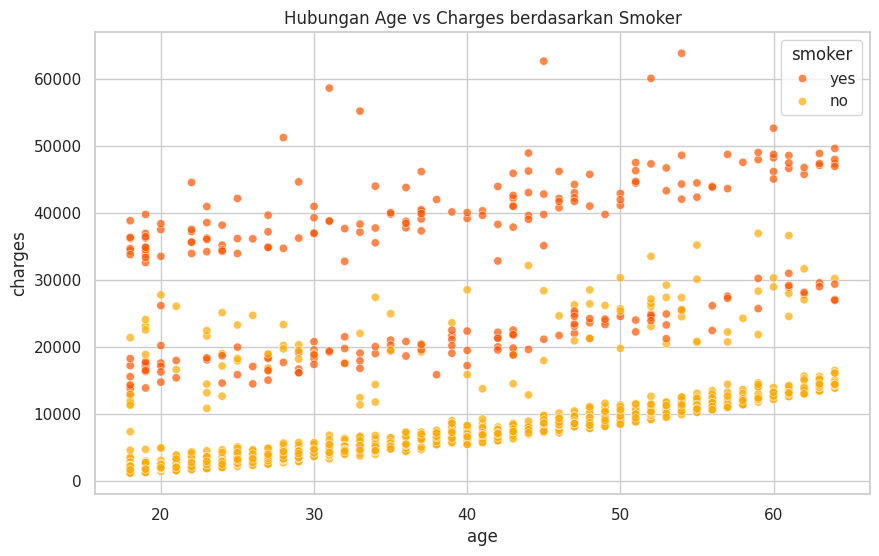

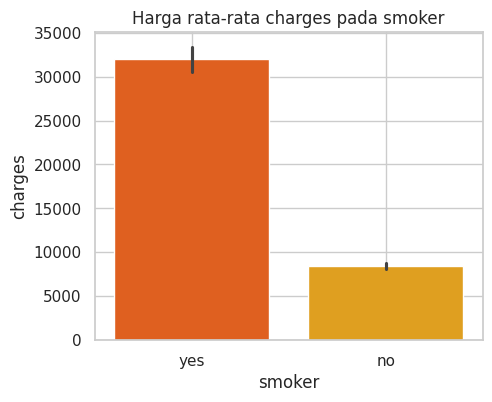

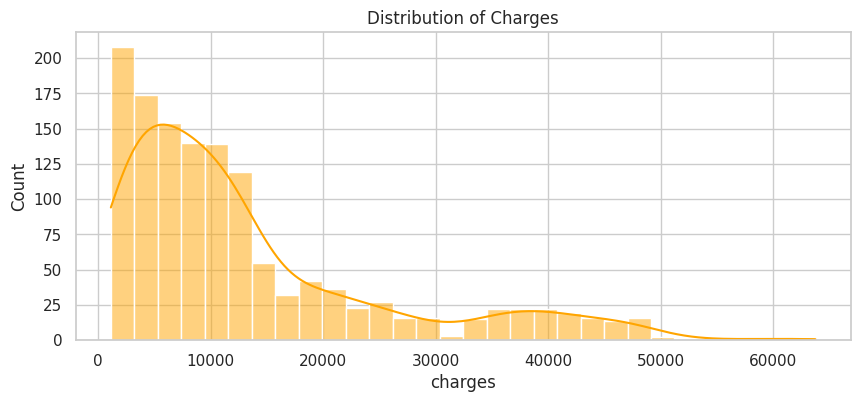

'\nmean = 13270\nstd = 12110\nmin = 1121\n25% = 4740\n50% = 9382\n75% = 16639\nmax = 63770\n'

In [42]:
# visualisasi Korelasi Merokok vs Biaya Premi

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', palette='autumn', alpha=0.7)
plt.title('Hubungan Age vs Charges berdasarkan Smoker')
plt.xlabel('age')
plt.ylabel('charges')
plt.grid(True)
plt.show()

print("========" * 12)

plt.figure(figsize=(5,4))
sns.barplot(x='smoker', y='charges', data=df, hue='smoker', palette='autumn')
plt.title("Harga rata-rata charges pada smoker")
plt.xlabel("smoker")
plt.ylabel("charges")
plt.grid(True)
plt.show

print("========" * 12)

plt.figure(figsize=(10,4))
sns.histplot(df['charges'], color='orange', kde=True)
plt.title('Distribution of Charges')
plt.show()


# INSIGHT:

# Analisa awalnya karena max charge begitu besar tidak merata berbanding median, biasanya tidak acak dan dipicu faktor tertentu. Kita harus secara objektif melihat korelasi feature dengan charge, smoker adalah yang paling mungkin dengan nalar logis (merokok penyakitan).
# Data barplot membuktikan smoker berpengaruh besar atas charge, karena avg charge pada org yg smoker terlampau tinggi dibanding yg tidak. Ini berarti bila orang smoker, maka akan membayar charge lebih mahal
# Charge distribution adalah visualisasi hasil dari statistik investigation. Ada outlier besar
# Terbukti charge right skewed, susunan matematis charge adalah :
"""
mean = 13270
std = 12110
min = 1121
25% = 4740
50% = 9382
75% = 16639
max = 63770
"""
# dari data tersebut bila digambar secara manual, kita akan melatih statistical intuition untuk membayangkan histplot di otak, mampu membuat hipotesis atau kesimpulan serta memahami data secara cepat

# Focus = Pattern, linear, cluster, outlier, distribution, noise

## BAB 3: Data Preparation
Algoritma Machine Learning (komputer) memiliki hukum pasti: **Mereka buta terhadap teks. Mereka hanya bisa memproses kalkulasi angka.**

### 3.1 Data Transformation (Encoding)
Kita harus mengubah semua data bertipe kategori/teks menjadi representasi angka.
* Teks binary ('yes'/'no') kita ubah pakai `.map()`.
* Teks dengan banyak kategori (seperti 'region') kita pecah pakai `.get_dummies()` (One-Hot Encoding).

In [43]:
# Mapping Teks Binary ke Angka
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df['sex'] = df['sex'].map({'female': 1, 'male': 0})

# One-Hot Encoding untuk kolom 'region'
df = pd.get_dummies(df, columns=['region'], drop_first=True)

# Cek hasil transformasi
display(df.head(3))

# INSIGHT :

# smoker dan sex mapplingnya = binary categorical (boolean)
# region = one-hot encoding (memecah menjadi kolom boolean baru)

# Focus = target leakage, encoding, imbalance, scaling, stratification

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.90,0,1,16884.9240,False,False,True
1,18,0,33.77,1,0,1725.5523,False,True,False
2,28,0,33.00,3,0,4449.4620,False,True,False


### 3.2 Pemisahan Fitur (X) dan Target (y)
* **X (Fitur):** Semua variabel pendukung (Umur, BMI, Status Merokok).
* **y (Target):** Hanya nilai Biaya Premi (Ini adalah jawaban yang akan ditebak mesin).

In [51]:
# X mengambil semua kolom KECUALI 'charges'
X = df.drop('charges', axis=1)
print(X.head(3))

print("========" * 12)
print("========" * 12)

# y mengambil HANYA kolom 'charges'
y = df['charges']
print(y.head(3))

# INSIGHT :
# x sebagai feature/var input dan y sebagai target prediction
# Focus = relevance feature, leakage, feature redundant, identifier, hidden target


   age  sex    bmi  children  smoker  region_northwest  region_southeast  \
0   19    1  27.90         0       1             False             False   
1   18    0  33.77         1       0             False              True   
2   28    0  33.00         3       0             False              True   

   region_southwest  
0              True  
1             False  
2             False  
0    16884.9240
1     1725.5523
2     4449.4620
Name: charges, dtype: float64


### 3.3 Data Splitting (Train Set & Test Set)
Kita membagi populasi data menjadi dua bagian yang tidak boleh bercampur:
* **Train Set (80%):** Data untuk melatih algoritma agar ia belajar memformulasikan pola.
* **Test Set (20%):** Data tersembunyi untuk menguji seberapa akurat prediksi algoritma tersebut pada data yang belum pernah ia lihat sebelumnya.

In [54]:
# Membelah data (80% Train, 20% Test)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Melihat dimensi hasil split

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# INSIGHT :
# Split data menjadi train set 80% dan test set 20%
# Mengapa 80/20, data belajar cukup, evaluasi representatif
# Underfitting = model gagal memahami underlying distribution pattern, fail dalam training maupun testing
# Overfitting = model terlalu presisi pada training data, gagal dalam performa testing data baru
# Generalization = model menghasilkan performa baik pada data baru yg tidak digunakan saat training

# Focus = enough data, distribution train/test balance, statify, leakage, time-series

X_train: (1070, 8)
X_test : (268, 8)
y_train: (1070,)
y_test : (268,)


## BAB 4: Modeling (Membangun dan Membedah Algoritma)
Kita tidak akan sekadar menjalankan fungsi `.fit()`. Kita akan membedah isi kepala (*under the hood*) dari 3 algoritma regresi paling populer untuk melihat bagaimana rumusnya bekerja.

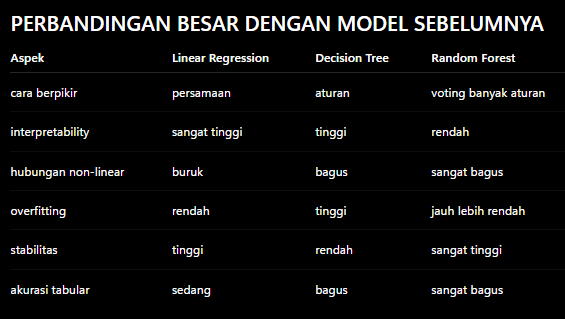

### 4.1 Linear Regression (Logika Garis Lurus)
Linear regression membuat persamaan matematika garis lurus $Y = (Bobot \times X) + Bias$. Mari kita latih modelnya dan bongkar rumus yang ia hasilkan!

In [55]:
# Inisialisasi dan Training
model_linear = LinearRegression()
model_linear.fit(X_train, y_train)

# MEMBONGKAR BLACK-BOX LINEAR REGRESSION
print("--- RUMUS MATEMATIKA YANG DIBUAT AI ---")

# Menampilkan bobot (coef_) dari salah satu fitur paling penting: 'smoker'
bobot_perokok = model_linear.coef_[X.columns.get_loc('smoker')]
bias_dasar = model_linear.intercept_
print(f"1. Nilai Bias/Tarif Dasar Asuransi : ${bias_dasar:,.2f}")
print(f"2. Denda Tambahan Jika Merokok     : +${bobot_perokok:,.2f}")

# Simulasi manual prediksi Linear Regression:
print("\n💡 Logika Mesin: 'Setiap nasabah yang merokok, saya akan tambahkan tarif preminya sebesar $23,651 secara otomatis!'")

# INSIGHT :
# Mudah dipahami, cepat, sebagai fondasi semua regression, baseline modeling, starting point teoritis
# Memodelkan korelasi input x dan target y menggunakan persamaan linier
# Meminimalkan eror = selisih prediksi dan jawaban asli
# Least square

# Focus = make sense, leakage, bias, multicollinearity, feature dominan


--- RUMUS MATEMATIKA YANG DIBUAT AI ---
1. Nilai Bias/Tarif Dasar Asuransi : $-11,949.81
2. Denda Tambahan Jika Merokok     : +$23,651.13

💡 Logika Mesin: 'Setiap nasabah yang merokok, saya akan tambahkan tarif preminya sebesar $23,651 secara otomatis!'


### 4.2 Decision Tree Regressor (Logika Percabangan If-Else)
Berbeda dengan garis lurus, Decision Tree bekerja dengan membelah data menjadi sekat-sekat keputusan. Mari kita buat satu model Decision Tree kecil (kedalaman cabang maksimal 2) agar kita bisa memvisualisasikan cara ia berpikir.

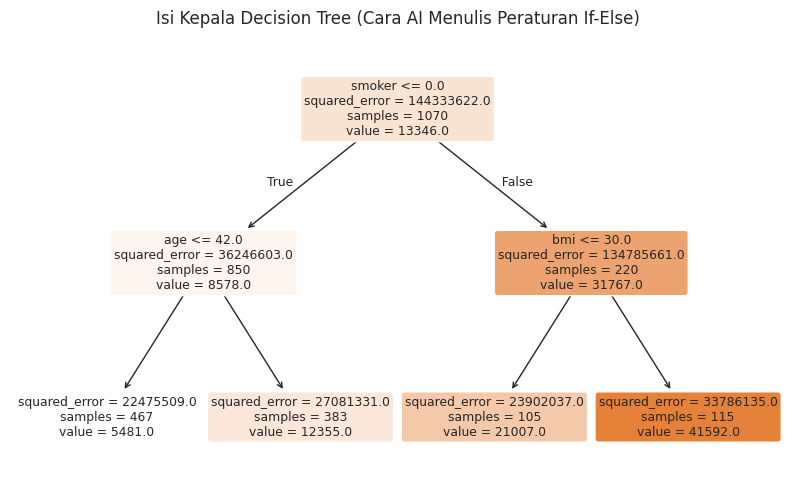

In [57]:
# Inisialisasi dan Training (Kita batasi max_depth=2 agar gambarnya muat)
model_tree_simulasi = DecisionTreeRegressor(max_depth=2, random_state=42)
model_tree_simulasi.fit(X_train, y_train)

# MEMBONGKAR BLACK-BOX DECISION TREE (Visualisasi Pohon)
plt.figure(figsize=(10, 6))
plot_tree(model_tree_simulasi, feature_names=X.columns, filled=True, rounded=True, precision=0)
plt.title("Isi Kepala Decision Tree (Cara AI Menulis Peraturan If-Else)")
plt.show()

# INSIGHT:
# Lihat kotak paling atas (Root). Pertanyaan pertamanya adalah: "Apakah smoker <= 0.5?" (Apakah dia BUKAN perokok?).
# Jika nasabah perokok (False), ia dilempar ke cabang kanan yang nilai prediksinya (value) langsung meledak tinggi!

### 4.3 Random Forest Regressor (Kekuatan Demokrasi)
Random Forest menciptakan *ratusan* Decision Tree secara acak. Prediksi akhirnya adalah **Nilai Rata-Rata** dari semua pohon tersebut. Mari kita buktikan konsensus demokrasinya!

In [106]:
# Inisialisasi dan Training (Membuat hutan dengan 250 pohon)
model_forest = RandomForestRegressor(n_estimators=250, random_state=42)
model_forest.fit(X_train, y_train)

# MEMBONGKAR BLACK-BOX RANDOM FOREST
# Kita ambil data 1 orang nasabah dari Test Set untuk disimulasikan
contoh_nasabah = X_test.iloc[[0]]

# Ambil tebakan dari Pohon ke-1, Pohon ke-2, dan Pohon ke-3 di dalam hutan
tebakan_pohon_1 = model_forest.estimators_[0].predict(contoh_nasabah.values)[0]
tebakan_pohon_2 = model_forest.estimators_[1].predict(contoh_nasabah.values)[0]
tebakan_pohon_3 = model_forest.estimators_[2].predict(contoh_nasabah.values)[0]

# Tebakan Final dari Hutan (Konsensus 100 pohon)
tebakan_final = model_forest.predict(contoh_nasabah)[0]

print("--- BUKTI DEMOKRASI RANDOM FOREST ---")
print(f"Prediksi Pohon #1 : ${tebakan_pohon_1:,.2f}")
print(f"Prediksi Pohon #2 : ${tebakan_pohon_2:,.2f}")
print(f"Prediksi Pohon #3 : ${tebakan_pohon_3:,.2f}")
print("...")
print(f" Prediksi Final Hutan (Rata-rata 100 pohon) : ${tebakan_final:,.2f}")

--- BUKTI DEMOKRASI RANDOM FOREST ---
Prediksi Pohon #1 : $8,603.82
Prediksi Pohon #2 : $8,515.76
Prediksi Pohon #3 : $8,604.48
...
 Prediksi Final Hutan (Rata-rata 100 pohon) : $10,568.71


## BAB 5: Evaluation (Menguji Performa Model)
Model AI sudah dilatih secara penuh. Sekarang, kita perintahkan mereka untuk menebak data **Test Set** (yang belum pernah mereka lihat). Kita akan ukur error-nya menggunakan metrik industri:
1. **MAE (Mean Absolute Error):** Nominal rata-rata jarak kesalahan prediksi (Semakin kecil semakin baik).
2. **R-Squared ($R^2$):** Persentase seberapa baik model mewakili pola data asli (Maksimal 1.0 atau 100%).

In [103]:
# Melatih ulang Decision Tree tanpa batasan max_depth untuk kompetisi asli
model_tree = DecisionTreeRegressor(random_state=42)
model_tree.fit(X_train, y_train)

# Melakukan Prediksi ke Data Test
pred_linear = model_linear.predict(X_test)
pred_tree = model_tree.predict(X_test)
pred_forest = model_forest.predict(X_test)

# Menghitung Rapor MAE
mae_linear = mean_absolute_error(y_test, pred_linear)
mae_tree = mean_absolute_error(y_test, pred_tree)
mae_forest = mean_absolute_error(y_test, pred_forest)

# Menghitung Rapor R-Squared
r2_linear = r2_score(y_test, pred_linear)
r2_tree = r2_score(y_test, pred_tree)
r2_forest = r2_score(y_test, pred_forest)

print("HASIL KOMPETISI ALGORITMA")
print(f"Linear Regression : MAE = ${mae_linear:,.0f} | R² = {r2_linear:.2f}")
print(f"Decision Tree     : MAE = ${mae_tree:,.0f} | R² = {r2_tree:.2f}")
print(f"Random Forest     : MAE = ${mae_forest:,.0f} | R² = {r2_forest:.2f}")

HASIL KOMPETISI ALGORITMA
Linear Regression : MAE = $4,181 | R² = 0.78
Decision Tree     : MAE = $3,224 | R² = 0.72
Random Forest     : MAE = $2,551 | R² = 0.87


### 5.1 Visualisasi Skor Error (MAE)
Mari kita gambarkan perbandingan tingkat error (melesetnya prediksi) dalam grafik batang agar mudah dipahami oleh manajemen bisnis.

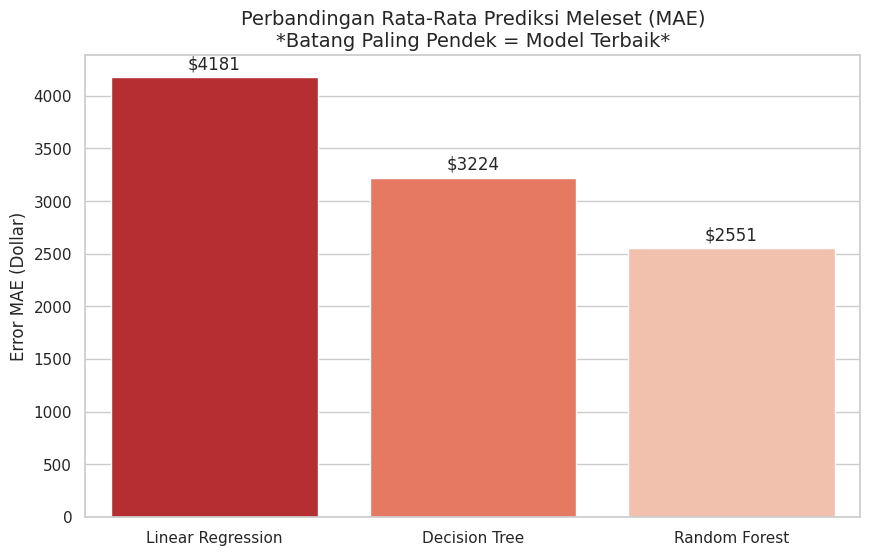

In [104]:
# Definisi model dan mae scores
model_names = ['Linear Regression', 'Decision Tree', 'Random Forest']
mae_scores = [mae_linear, mae_tree, mae_forest]

# visualisasi menggunakan barplot
plt.figure(figsize=(10, 6))
bars = sns.barplot(x=model_names, y=mae_scores, hue=model_names, palette='Reds_r')

# Menampilkan nominal angka di puncak grafik
for bar in bars.containers:
    bars.bar_label(bar, fmt='$%.0f', padding=3)
plt.title('Perbandingan Rata-Rata Prediksi Meleset (MAE)\n*Batang Paling Pendek = Model Terbaik*', fontsize=14)
plt.ylabel('Error MAE (Dollar)')
plt.show()
# INSIGHT: Random Forest adalah pemenang mutlak! Melesetnya paling kecil.

### 5.2 Realitas Uji Lapangan (Actual vs Predicted Scatter Plot)
Untuk menutup presentasi ke klien, kita akan membuat *Scatter Plot* khusus untuk membuktikan akurasi sang pemenang (Random Forest). Sumbu X adalah **Tarif Asli ($Y\_test$)** dan sumbu Y adalah **Tarif Tebakan AI ($Prediksi$)**.

*Jika AI kita sempurna (Akurasi 100%), semua titik akan membentuk satu garis lurus menyilang diagonal!*

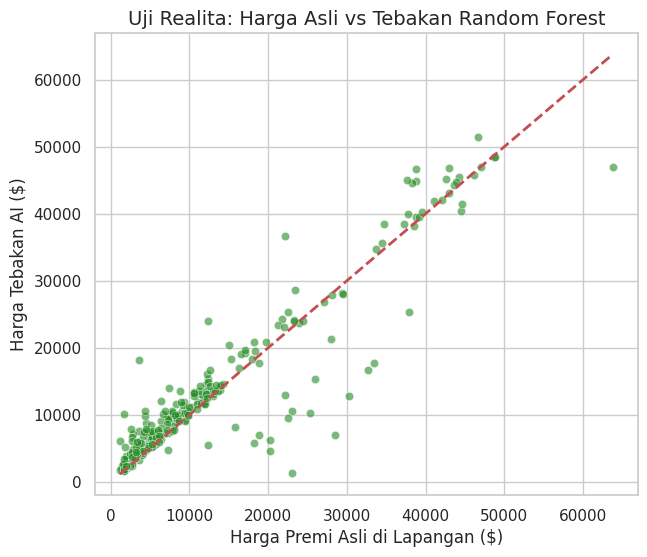

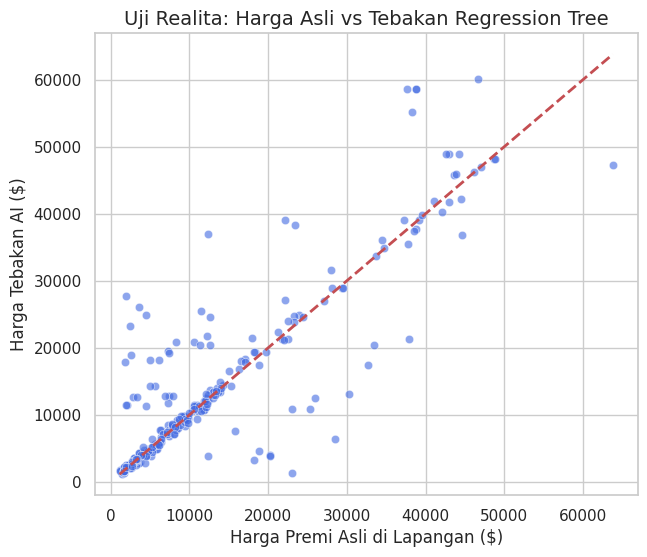

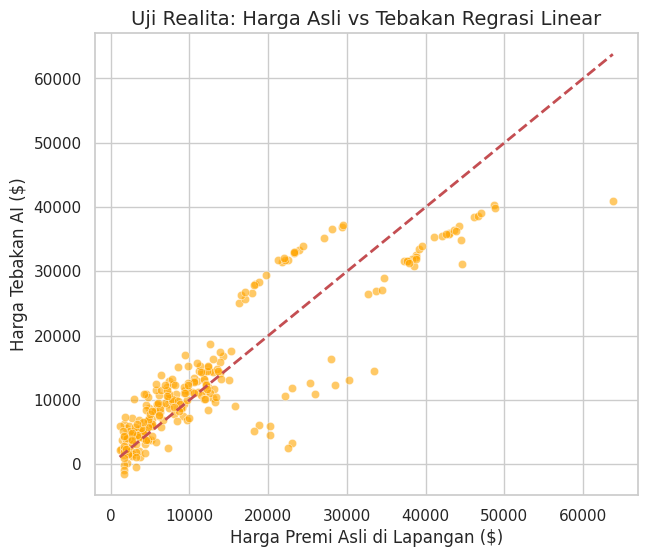

In [105]:
plt.figure(figsize=(7, 6))

# Titik tebakan Random Forest
sns.scatterplot(x=y_test, y=pred_forest, color='forestgreen', alpha=0.6)

# Garis Kesempurnaan (Diagonal)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Uji Realita: Harga Asli vs Tebakan Random Forest', fontsize=14)
plt.xlabel('Harga Premi Asli di Lapangan ($)')
plt.ylabel('Harga Tebakan AI ($)')
plt.show()

# KESIMPULAN AKHIR:
# Titik-titik hijau berkumpul sangat rapat memeluk garis diagonal merah (terutama di kelas harga menengah-bawah).
# Ini membuktikan Random Forest kita siap di-deploy (digunakan) oleh perusahaan asuransi!

print("========" * 11)
print("========" * 11)

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=pred_tree, color='royalblue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Uji Realita: Harga Asli vs Tebakan Regression Tree', fontsize=14)
plt.xlabel('Harga Premi Asli di Lapangan ($)')
plt.ylabel('Harga Tebakan AI ($)')
plt.show()

print("========" * 11)
print("========" * 11)

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=pred_linear, color='orange', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Uji Realita: Harga Asli vs Tebakan Regrasi Linear', fontsize=14)
plt.xlabel('Harga Premi Asli di Lapangan ($)')
plt.ylabel('Harga Tebakan AI ($)')
plt.show()

# AKHIR DARI FASE REGRESI
Selamat! Anda baru saja melewati seluruh siklus **CRISP-DM** dan berhasil membongkar "kotak hitam" cara kerja algoritma Machine Learning. Anda juga membuktikan mengapa metode kelompok (*Ensemble*) selalu mengalahkan model individu dalam kompetisi AI.

### TAKE-HOME MISSION (Hyperparameter Tuning)
Algoritma Random Forest kita menang menggunakan "setelan pabrik" (100 pohon). Tugas Anda di rumah:
Bisakah Anda membuat nilai MAE-nya lebih kecil lagi?
1. *Copy* kode inisialisasi Random Forest di atas.
2. Ubah parameternya menjadi `RandomForestRegressor(n_estimators=300, min_samples_split=5, random_state=42)`.
3. Latih ulang dan cek apakah skor error-nya berkurang!


### Sudah dilakukan, yang paling tepat adalah n_estimators=250. Berhasil mengubah skor error (R) menjadi 0.87 (naik 0.01), yg berarti model sedikit bertambah bagus/presisi dari sebelumnya.

---
## Referensi & Tempat Belajar Mandiri (Supervised Learning - Regression)

Proses pemodelan *Machine Learning* membutuhkan kombinasi antara intuisi bisnis, pemahaman algoritma, dan validasi metrik yang ketat. Untuk memperdalam taktik optimasi model Regresi yang telah kita pelajari melalui kerangka **CRISP-DM** hari ini, Anda dapat menjelajahi sumber daya resmi industri berikut:

### 1. Dokumentasi Resmi & Alkitab Pemodelan (Scikit-Learn)
* **Website:** [scikit-learn.org](https://scikit-learn.org/stable/)
* **Fungsi Utama:** Kiblat utama global untuk memahami seluruh parameter (*hyperparameters*) dari algoritma yang kita gunakan hari ini.
    * **Linear Regression Guide:** [Supervised Linear Models](https://scikit-learn.org/stable/modules/linear_model.html)
    * **Decision Trees Guide:** [Tree-based Models](https://scikit-learn.org/stable/modules/tree.html)
    * **Random Forest Guide:** [Ensemble Methods](https://scikit-learn.org/stable/modules/ensemble.html)

### 2. Rumah Eksperimen & Komunitas Data Science (Kaggle Code)
* **Website:** [kaggle.com/code](https://www.kaggle.com/code)
* **Fungsi Utama:** Mencari referensi nyata bagaimana para *Data Grandmasters* melakukan rekayasa fitur (*Feature Engineering*) dan menekan skor error MAE menjadi seminimal mungkin pada berbagai data industri.
* **Rekomendasi Kata Kunci Pencarian di Kaggle:**
    * `Medical Insurance Cost Regression`
    * `House Price Prediction Advanced Regression`
    * `Hyperparameter Tuning Random Forest Regressor`

### 3. Visualisasi Konsep Matematika & Statistika (StatQuest)
* **Website:** [StatQuest dengan Josh Starmer (YouTube)](https://www.youtube.com/@statquest)
* **Fungsi Utama:** Kanal visual terbaik untuk membongkar algoritma kompleks menjadi konsep yang sangat sederhana. Sangat direkomendasikan untuk memahami logika internal bagaimana *Random Forest* membangun ratusan pohon keputusan lewat animasi tanpa membuat kepala pusing.
    * **Rekomendasi Video:** *Linear Regression, Decision Trees, and Random Forests Explained.*

---

### Kesalahan Umum Pemula pada Tahap Pemodelan Regresi:
2.  **Lupa Melakukan Encoding Teks:** Memasukkan kolom teks murni langsung ke dalam algoritma Scikit-Learn tanpa transformasi angka binary atau *One-Hot Encoding*.
3.  **Mengabaikan Nilai MAE:** Terlalu fokus pada nilai $R^2$ yang tinggi tanpa melihat berapa nominal melesetnya prediksi secara riil di lapangan melalui nilai *Mean Absolute Error*.

*Simpan amunisi referensi ini dengan baik. Persiapkan diri Anda untuk materi besok di Hari Terakhir: **Supervised Learning - Classification Path!***